<a href="https://colab.research.google.com/github/Alejandra300905/ocupacion-pista-atletismo-opencv/blob/main/notebooks/ProyectoPistaAtletismoAleBJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# PARÁMETROS CONFIGURABLES
#este bloque no detecta todavía nada. Solo define los parámetros que van a controlar qué se considera ruido,
#qué se considera persona, qué tan fuerte se limpian las imágenes y cómo se calcula la ocupación de la pista.

RUTA_REFERENCIA = "../imagenes/referencia/img21.jpeg"
RUTA_PRUEBA = "../imagenes/prueba/img24.png"

# Tamaño de los blobs aceptados como persona
AREA_MIN = 100     #Hay corredores mas pequenos
AREA_MAX = 25000

CAPACIDAD_MAXIMA = 24

# Suavizado y morfologia
KERNEL_GAUSS = (5, 5)

KERNEL_APERTURA = (3, 3)

KERNEL_CIERRE_VERTICAL = (3, 13)

# Umbral fijo en lugar de Otsu (Otsu elegia 12/255, demasiado sensible)
UMBRAL_FIJO = 40

# Filtros para descartar FALSOS POSITIVOS y formas no humanas

EXTENT_MIN = 0.18
ALTURA_MIN = 8
PROP_MIN   = 0.6
PROP_MAX   = 6.0

MARGEN_FUSION = 8   # problema de torso + piernas.

In [4]:
def mostrar(imagen, titulo, gris=False):
    plt.figure(figsize=(9, 6))
    if gris:
        plt.imshow(imagen, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis("off")
    plt.show()

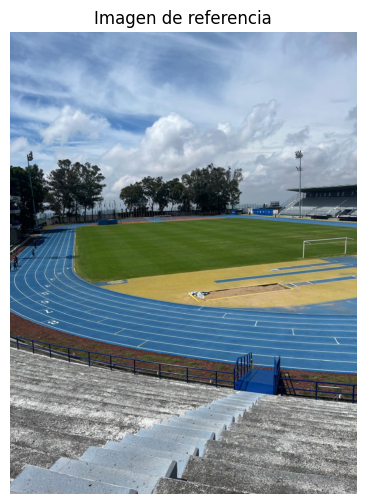

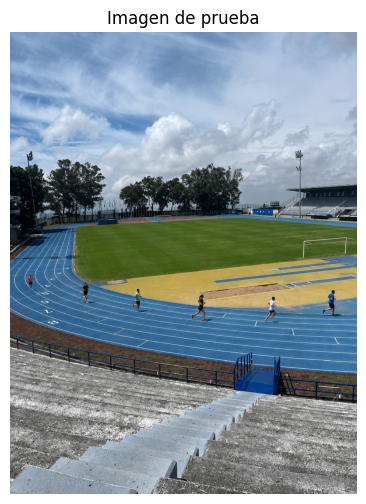

In [5]:
# CARGA Y REDIMENSIONADO

assert os.path.exists(RUTA_REFERENCIA), "No existe la imagen de referencia"
assert os.path.exists(RUTA_PRUEBA),     "No existe la imagen de prueba"

img_referencia = cv2.imread(RUTA_REFERENCIA)
img_prueba     = cv2.imread(RUTA_PRUEBA)

assert img_referencia is not None
assert img_prueba is not None

alto, ancho = img_prueba.shape[:2]

img_referencia = cv2.resize(img_referencia, (ancho, alto))

mostrar(img_referencia, "Imagen de referencia")
mostrar(img_prueba,     "Imagen de prueba")

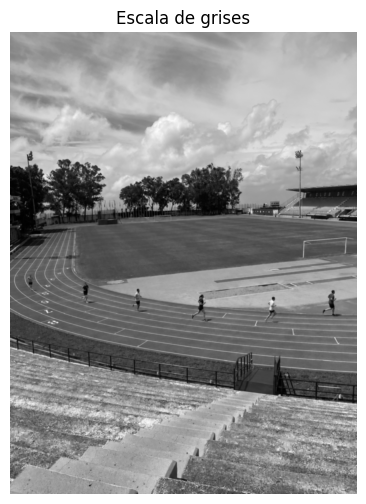

In [6]:
# PREPROCESAMIENTO: ESCALA DE GRISES + BLUR

gris_ref   = cv2.cvtColor(img_referencia, cv2.COLOR_BGR2GRAY)
gris_prueba = cv2.cvtColor(img_prueba,    cv2.COLOR_BGR2GRAY)

gris_ref    = cv2.GaussianBlur(gris_ref,    KERNEL_GAUSS, 0)
gris_prueba = cv2.GaussianBlur(gris_prueba, KERNEL_GAUSS, 0)

mostrar(gris_prueba, "Escala de grises", gris=True)

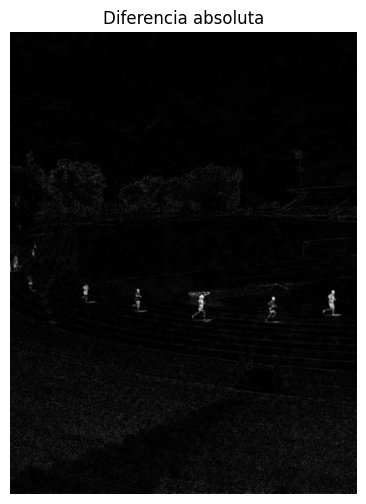

In [7]:
# DIFERENCIA ABSOLUTA

diferencia = cv2.absdiff(gris_prueba, gris_ref)

mostrar(diferencia, "Diferencia absoluta", gris=True)

Umbral aplicado: 40.0


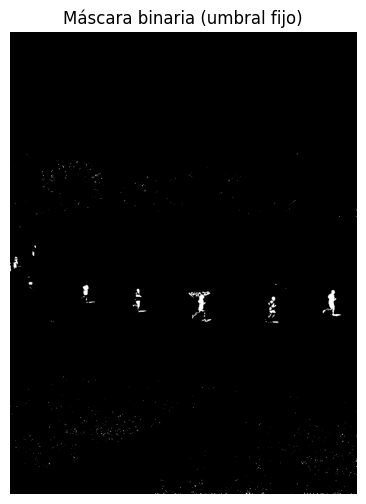

In [8]:
# UMBRALIZACIÓN - AJUSTE: umbral fijo en lugar de Otsu
# Otsu eligió 12/255 porque los corredores son una fracción pequeña de la imagen,
# lo que confundió al algoritmo y marcó casi cualquier cambio de brillo como objeto.
# Con un umbral fijo de 40 solo se detectan cambios significativos.

umbral_valor, binaria = cv2.threshold(
    diferencia,
    UMBRAL_FIJO,   # AJUSTE: valor fijo; ajustar entre 30-60 según la imagen
    255,
    cv2.THRESH_BINARY   # AJUSTE: se elimina THRESH_OTSU
)

print("Umbral aplicado:", umbral_valor)

mostrar(binaria, "Máscara binaria (umbral fijo)", gris=True)

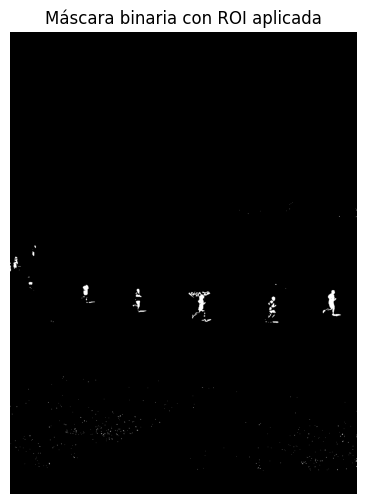

In [9]:
# MÁSCARA ROI - AJUSTE: delimitar solo la pista azul
# La pista azul ocupa una franja horizontal en la imagen.
# Se define un polígono que la cubre y se ignoran árboles (parte superior)
# y escaleras (esquina inferior izquierda).
# IMPORTANTE: ajusta los vértices del polígono según tu imagen específica.

roi_mask = np.zeros((alto, ancho), dtype=np.uint8)

# Polígono que aproxima la zona de la pista azul.
# Los valores son proporciones del alto/ancho total para que sean independientes
# de la resolución. Modifica estos puntos arrastrándolos visualmente si es necesario.
puntos_roi = np.array([[
    (int(ancho * 0.00), int(alto * 0.45)),   # borde izquierdo, ~45% de la altura
    (int(ancho * 1.00), int(alto * 0.35)),   # borde derecho,  ~35% de la altura
    (int(ancho * 1.00), int(alto * 0.95)),   # esquina inferior derecha
    (int(ancho * 0.00), int(alto * 0.95)),   # esquina inferior izquierda
]], dtype=np.int32)

cv2.fillPoly(roi_mask, puntos_roi, 255)

# Aplicar la máscara ROI a la imagen binaria antes de la morfología
binaria = cv2.bitwise_and(binaria, binaria, mask=roi_mask)

mostrar(binaria, "Máscara binaria con ROI aplicada", gris=True)

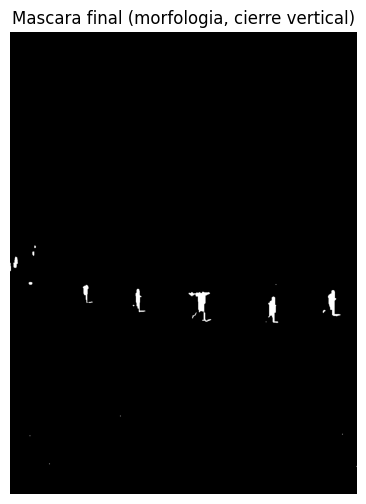

In [10]:
# MORFOLOGIA: APERTURA + CIERRE

k_ap = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, KERNEL_APERTURA)

# AJUSTE: el cierre usa un kernel VERTICAL (mas alto que ancho), no cuadrado.
# MOTIVO: un corredor en plena zancada se separa en torso + piernas con un hueco
# a la altura de la cintura. Con RETR_EXTERNAL eso se veia como 2 contornos y la
# persona se contaba DOS veces. Un kernel vertical une lo que esta separado en
# vertical (asi esta hecho el cuerpo humano) SIN pegar a corredores vecinos,
# porque ellos estan separados en horizontal.
k_ci = cv2.getStructuringElement(cv2.MORPH_RECT, KERNEL_CIERRE_VERTICAL)

# Apertura: elimina manchas pequenas (ruido de hojas, bordes)
apertura = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, k_ap, iterations=1)

# Cierre vertical: une el cuerpo de un mismo corredor en un solo blob
mascara = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, k_ci, iterations=2)

mostrar(mascara, "Mascara final (morfologia, cierre vertical)", gris=True)

In [11]:
# DETECCION DE CONTORNOS Y CONTEO

contornos, _ = cv2.findContours(
    mascara,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# PASO 1: recolectar cajas candidatas (todavia sin contar).
# Aqui se aplican los filtros que limpian el FALSO POSITIVO del fondo.
cajas = []
for c in contornos:

    area = cv2.contourArea(c)
    if not (AREA_MIN <= area <= AREA_MAX):
        continue

    x, y, w, h = cv2.boundingRect(c)

    # AJUSTE: filtro de RELLENO (extent). El cuadro fantasma del fondo y el ruido
    # de bordes son blobs delgados/dispersos -> extent bajo -> se descartan.
    extent = area / float(w * h) if w * h > 0 else 0
    if extent < EXTENT_MIN:
        continue

    # AJUSTE: alto minimo en pixeles (descarta manchitas planas del piso)
    if h < ALTURA_MIN:
        continue

    # AJUSTE: proporcion alto/ancho mas permisiva que antes (0.6 en vez de 1.0),
    # para no descartar corredores validos.
    proporcion = h / w if w != 0 else 0
    if proporcion < PROP_MIN or proporcion > PROP_MAX:
        continue

    cajas.append([x, y, w, h])

# PASO 2: FUSIONAR cajas que se traslapan o estan casi pegadas.
# AJUSTE: red de seguridad para "una persona contada como 2". Si quedaran restos
# de un mismo corredor partidos, se unen en una sola caja antes de contar.
def se_traslapan(a, b, margen):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    # se infla cada caja 'margen' pixeles y se revisa si chocan
    ax -= margen; ay -= margen; aw += 2 * margen; ah += 2 * margen
    return not (ax + aw < bx or bx + bw < ax or ay + ah < by or by + bh < ay)

def fusionar_cajas(cajas, margen):
    cambiado = True
    while cambiado:
        cambiado = False
        nuevas = []
        while cajas:
            x, y, w, h = cajas.pop(0)
            i = 0
            while i < len(cajas):
                if se_traslapan([x, y, w, h], cajas[i], margen):
                    x2, y2, w2, h2 = cajas.pop(i)
                    nx = min(x, x2); ny = min(y, y2)
                    nx2 = max(x + w, x2 + w2); ny2 = max(y + h, y2 + h2)
                    x, y, w, h = nx, ny, nx2 - nx, ny2 - ny
                    cambiado = True
                else:
                    i += 1
            nuevas.append([x, y, w, h])
        cajas = nuevas
    return cajas

cajas = fusionar_cajas(cajas, MARGEN_FUSION)

# PASO 3: dibujar y contar (una caja = un corredor)
img_resultado = img_prueba.copy()
corredores = 0
area_total = 0

for (x, y, w, h) in cajas:
    corredores += 1
    area_total += w * h

    cv2.rectangle(img_resultado, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.putText(img_resultado, str(corredores), (x, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

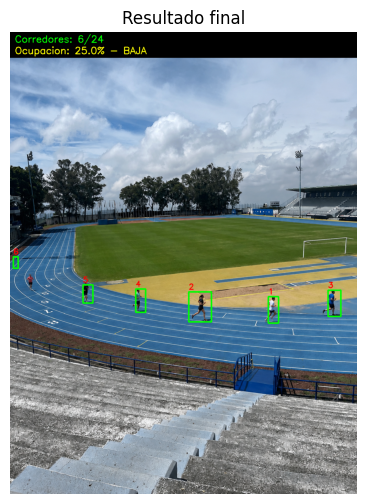

In [12]:
# CÁLCULO DE OCUPACIÓN Y ETIQUETA

porcentaje = corredores / CAPACIDAD_MAXIMA * 100
porcentaje = min(porcentaje, 100)

if porcentaje < 33:
    nivel = "BAJA"
elif porcentaje < 66:
    nivel = "MEDIA"
else:
    nivel = "ALTA"

texto1 = f"Corredores: {corredores}/{CAPACIDAD_MAXIMA}"
texto2 = f"Ocupacion: {porcentaje:.1f}% - {nivel}"

cv2.rectangle(img_resultado, (0, 0), (ancho, 80), (0, 0, 0), -1)

cv2.putText(img_resultado, texto1, (15, 32),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

cv2.putText(img_resultado, texto2, (15, 68),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

mostrar(img_resultado, "Resultado final")

In [13]:
# RESUMEN EN CONSOLA

print("=" * 40)
print("RESULTADOS")
print("=" * 40)
print("Umbral aplicado:", umbral_valor)
print("Corredores detectados:", corredores)
print("Capacidad:", CAPACIDAD_MAXIMA)
print(f"Ocupación: {porcentaje:.1f}%")
print("Nivel:", nivel)

RESULTADOS
Umbral aplicado: 40.0
Corredores detectados: 6
Capacidad: 24
Ocupación: 25.0%
Nivel: BAJA


Imagen guardada en: /content/drive/MyDrive/pista/resultado_final.jpg


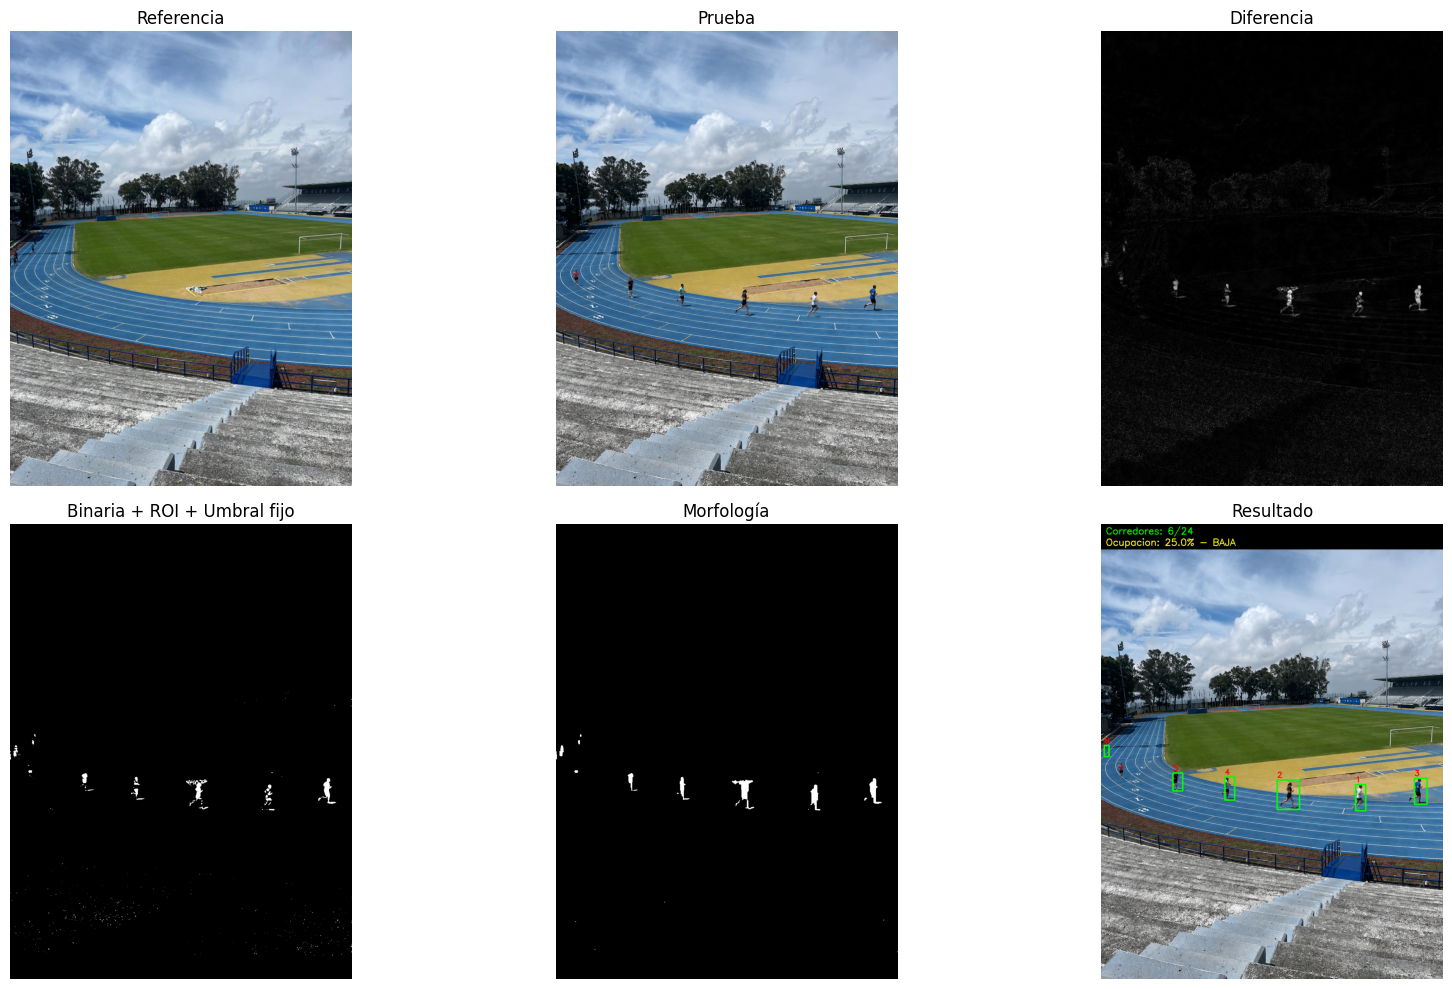

In [14]:
# GUARDADO Y MOSAICO FINAL

RUTA_SALIDA = RUTA_SALIDA = "../resultados/resultado_final.jpg"
cv2.imwrite(RUTA_SALIDA, img_resultado)
print("Imagen guardada en:", RUTA_SALIDA)

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].imshow(cv2.cvtColor(img_referencia, cv2.COLOR_BGR2RGB))
ax[0, 0].set_title("Referencia")

ax[0, 1].imshow(cv2.cvtColor(img_prueba, cv2.COLOR_BGR2RGB))
ax[0, 1].set_title("Prueba")

ax[0, 2].imshow(diferencia, cmap="gray")
ax[0, 2].set_title("Diferencia")

ax[1, 0].imshow(binaria, cmap="gray")
ax[1, 0].set_title("Binaria + ROI + Umbral fijo")

ax[1, 1].imshow(mascara, cmap="gray")
ax[1, 1].set_title("Morfología")

ax[1, 2].imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
ax[1, 2].set_title("Resultado")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()